### **made by: Shreya**

# Takens Embedding: From Dynamical Systems to ECG Classification

This tutorial demonstrates how delay-coordinate embeddings allow us to reconstruct
hidden dynamical structure from scalar time series, and how topological features
of these reconstructions can be used for robust classification of biomedical signals.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting
from scipy.integrate import solve_ivp
from IPython.display import Image

from ripser import ripser
from gtda.diagrams import PersistenceEntropy
from persim import plot_diagrams

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import neurokit2 as nk


ModuleNotFoundError: No module named 'neurokit2'

A dynamical system describes how a state evolves over time.
Phase space provides a geometric view of this evolution, where each axis represents
one state variable.

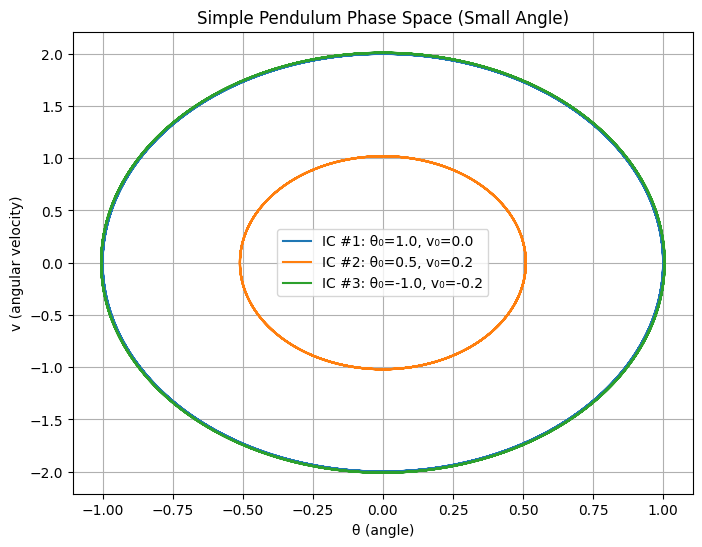

In [2]:
"""
- first, we define and simulate the dynamics of a simple pendulum under the small-angle approximation
- then express the second-order ODE θ'' + ω² θ = 0 as a system of first-order ODEs
- and solve it numerically for three distinct initial conditions spanning different angles and angular velocities
- then plot angle vs angular velocity in phase space to visualize how the pendulum's state evolves over time
- finally, we can observe how different starting points influence the trajectories and understand the geometry of simple oscillatory dynamics
"""


omega = 2.0
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

def pendulum_ode(t, y):
    theta, v = y
    dtheta_dt = v
    dv_dt = -omega**2 * theta
    return [dtheta_dt, dv_dt]

initial_conditions = [
    (1.0, 0.0),
    (0.5, 0.2),
    (-1.0, -0.2)
]

plt.figure(figsize=(8, 6))
for idx, ic in enumerate(initial_conditions):
    sol = solve_ivp(pendulum_ode, t_span, ic, t_eval=t_eval)
    theta = sol.y[0]
    v = sol.y[1]
    plt.plot(theta, v, label=f'IC #{idx+1}: \u03b8\u2080={ic[0]}, v\u2080={ic[1]}')

plt.xlabel('\u03b8 (angle)')
plt.ylabel('v (angular velocity)')
plt.title('Simple Pendulum Phase Space (Small Angle)')
plt.legend()
plt.grid(True)
plt.show()


Each initial condition produces a closed orbit in phase space.
Although the time evolution differs, the geometric structure remains invariant.

This code solves the simple pendulum's motion equations under the small-angle simplification and shows how the pendulum oscillates and how different initial states lead to distinct but predictable elliptical paths.

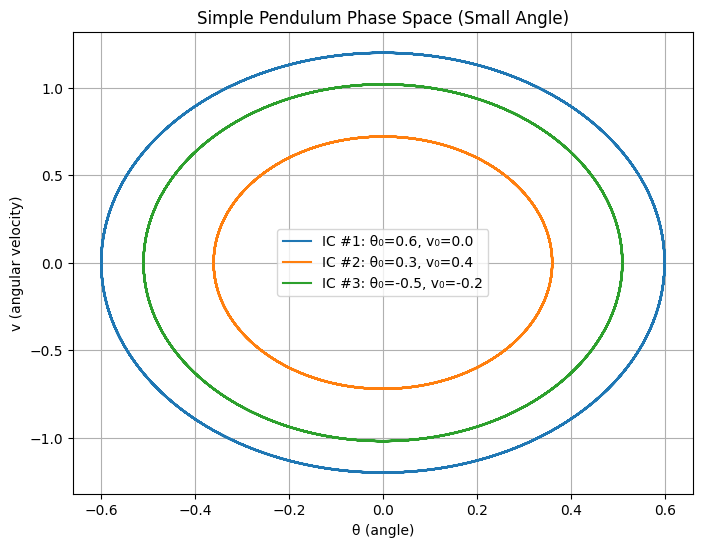

In [16]:
initial_conditions = [
    (0.6, 0.0),   
    (0.3, 0.4),   
    (-0.5, -0.2)  
]


plt.figure(figsize=(8, 6))
extended_t_span = (0, 40)
extended_t_eval = np.linspace(extended_t_span[0], extended_t_span[1], 2000)

for idx, ic in enumerate(initial_conditions):
    sol = solve_ivp(pendulum_ode, extended_t_span, ic, t_eval=extended_t_eval)
    theta = sol.y[0]
    v = sol.y[1]
    plt.plot(theta, v, label=f'IC #{idx+1}: θ₀={ic[0]}, v₀={ic[1]}')

plt.xlabel('θ (angle)')
plt.ylabel('v (angular velocity)')
plt.title('Simple Pendulum Phase Space (Small Angle)')
plt.legend()
plt.grid(True)
plt.show()


### Phase Space: Simple Pendulum (Small Angle)

Each coloured loop in the plot represents the phase space trajectory of the pendulum
for a different initial condition (initial angle and/or velocity), defined by an initial angle `theta` and an
initial angular velocity `theta_dot`.


Phase space here is a two-dimensional space with:
- horizontal axis: `theta` (angle)
- vertical axis: `theta_dot` (angular velocity)

Key observations:

- Higher mechanical energy (larger initial angle and/or larger initial angular velocity)
  results in a larger ellipse in phase space.
- All trajectories are closed curves, meaning the motion is perfectly periodic:
  if the pendulum starts from the same point in phase space, it will repeat its motion exactly.
- All ellipses are centered at the origin (theta, theta_dot) and are aligned
  with the coordinate axes. The ellipses do not tilt or shift in phase space.

In short:
Different initial conditions correspond to different constant-energy levels.
Each energy level produces a distinct elliptical orbit in phase space.
The shape, orientation, and center of the ellipse remain fixed; only the size changes.
Each loop therefore acts as an “energy signature” of the initial state.

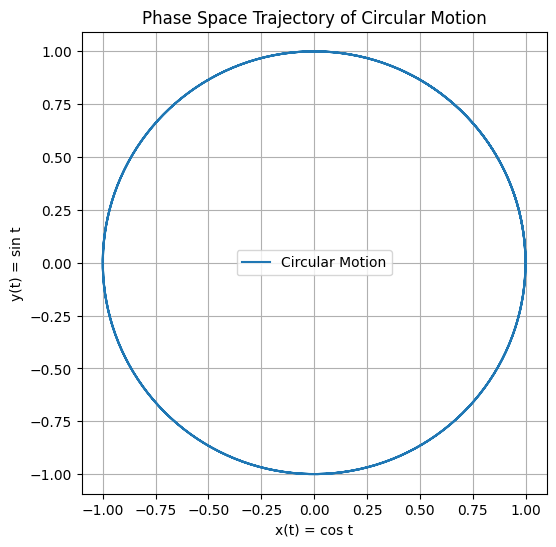

In [4]:
"""
- here, we'll simulate uniform circular motion by parameterizing it as (x(t), y(t)) = (cos t, sin t)
- then generate values for x and y over time
- and plot their trajectory in (x, y) phase space
- finally, visualize the constant-speed 'rotation' around a circle and compare its phase space geometry to the pendulum's
"""


t = np.linspace(0, 20, 1000)
x = np.cos(t)
y = np.sin(t)

plt.figure(figsize=(6, 6))
plt.plot(x, y, label='Circular Motion')
plt.xlabel('x(t) = cos t')
plt.ylabel('y(t) = sin t')
plt.title('Phase Space Trajectory of Circular Motion')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


Circular motion provides an explicit example of a system whose dynamics lie on a
1-dimensional manifold embedded in higher-dimensional space.

This code generates a uniform circular motion using cosine and sine functions to create x and y coordinates over time. By plotting these points in 2D phase space, we can see how simple periodic motion manifests as closed loops in phase space, contrasting with the elliptical orbits of the pendulum and reinforcing concepts of dynamical system trajectories.


### Comparing Simple Pendulum vs Circular Motion Phase Space


#### Simple Pendulum (Small Angle Approximation)

- Phase space trajectory is an **ellipse**, characteristic of simple harmonic motion.
- Coordinates are:
  - `theta` = angular displacement
  - `theta_dot` = angular velocity
- Motion oscillates back and forth around the stable equilibrium at `theta = 0`.
- Mechanical energy determines the **size** of the ellipse:
  larger initial angle or larger initial angular velocity gives a larger ellipse.
- All trajectories are centered at the origin and aligned with the coordinate axes.
- Direction of motion reverses every half-cycle, reflecting oscillatory behavior.

---

#### Circular Motion

- Phase space trajectory is a **perfect circle** with constant radius.
- Coordinates are:
  - `x = cos(t)`
  - `y = sin(t)`
- Motion proceeds continuously in a single direction without reversal.
- Energy remains constant and identical for all time, reflected by the fixed circle radius.
- The system traces the same closed orbit repeatedly with uniform speed.

---

#### TL;DR

Both systems are periodic and produce closed curves in phase space, but their dynamics differ:

- The simple pendulum oscillates, producing energy-dependent elliptical orbits.
- Circular motion rotates uniformly, producing a single fixed circular orbit.

In short, both repeat forever, but one **swings back and forth**, while the other
**keeps rotating smoothly in one direction**.


### What These Examples Reveal About Dynamical Systems

Abstractly, a dynamical system is a rule that maps a state forward in time.
Despite differing equations, systems may share the same qualitative phase space
structure.

From these examples, we observe that both the simple pendulum (under the small-angle
approximation) and circular motion are classic examples of dynamical systems.
In each case, the state of the system—described by position and velocity variables—
evolves over time according to well-defined differential equations.

For the simple pendulum, we observe that mechanical energy continuously exchanges
between potential energy (due to height) and kinetic energy (due to motion).
This conservation of energy leads to closed, elliptical trajectories in phase space.
In contrast, for circular motion, the position evolves along a perfect circle with
constant speed and fixed radius, indicating uniform and highly regular dynamics.

What makes these systems dynamical is that, once the initial conditions are specified,
every future state of the system is uniquely determined by the governing equations.
As a result, their phase space trajectories are predictable and repeatable, provided
the system is not disturbed.

Finally, we observe that this idea extends beyond continuous-time systems.
The same principles apply to discrete dynamical systems, such as the logistic map,
where a rule iteratively updates the state in time.
Together, these examples illustrate the general concept of a dynamical system:
a mathematical framework in which simple rules generate structured, time-evolving behavior.


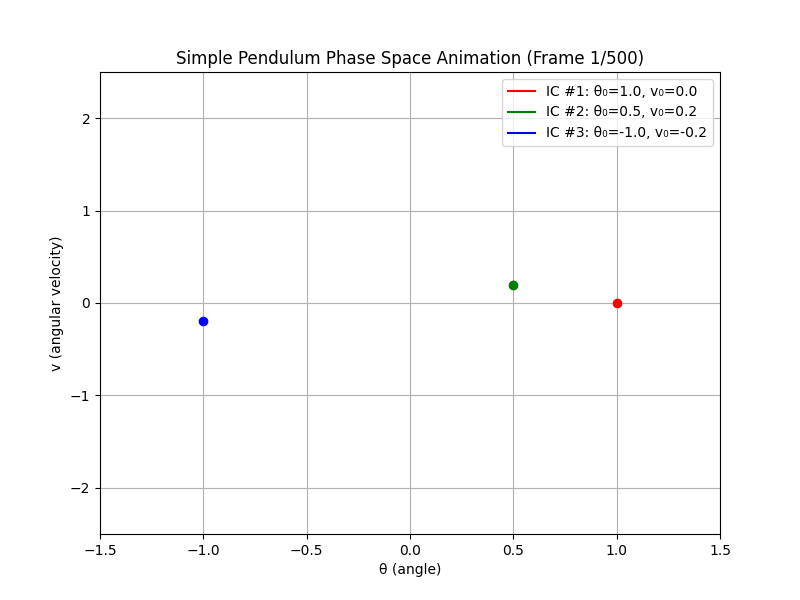

In [13]:
"""
- first, we create an animation of the simple pendulum's phase space trajectories using matplotlib and save it as a GIF file.
- then numerically solve the pendulum ODE for three different initial conditions.
- and animate the growth of their trajectories over time.
- then handle initialization by setting plot elements to NaN and check array lengths before updating the marker positions.
- finally, save the animation as a GIF to allow visualization in environments that don't support live plotting, such as Google Colab.
"""



omega = 2.0
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 500)

def pendulum_ode(t, y):
    theta, v = y
    return [v, -omega**2 * theta]

initial_conditions = [
    (1.0, 0.0),
    (0.5, 0.2),
    (-1.0, -0.2)
]

solutions = []
for ic in initial_conditions:
    sol = solve_ivp(pendulum_ode, t_span, ic, t_eval=t_eval)
    solutions.append(sol)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel('θ (angle)')
ax.set_ylabel('v (angular velocity)')
ax.set_title('Simple Pendulum Phase Space Animation')
ax.grid(True)

colors = ['r', 'g', 'b']
lines = [ax.plot([], [], color=colors[i], label=f'IC #{i+1}: θ₀={ic[0]}, v₀={ic[1]}')[0] for i, ic in enumerate(initial_conditions)]
points = [ax.plot([], [], 'o', color=colors[i])[0] for i in range(len(initial_conditions))]

ax.legend()

def init():
    for line, point in zip(lines, points):
        line.set_data([], [])
        point.set_data([np.nan], [np.nan])
    return lines + points

def animate(frame):
    ax.set_title(f'Simple Pendulum Phase Space Animation (Frame {frame}/{len(t_eval)})')
    for i, sol in enumerate(solutions):
        theta = sol.y[0, :frame]
        v = sol.y[1, :frame]
        lines[i].set_data(theta, v)
        if len(theta) > 0 and len(v) > 0:
            points[i].set_data([theta[-1]], [v[-1]])
        else:
            points[i].set_data([np.nan], [np.nan])
    return lines + points

ani = FuncAnimation(
    fig, animate, frames=range(1, len(t_eval)+1),
    init_func=init, blit=False, interval=40, repeat=False
)

ani.save("pendulum_phase_space.gif", writer='pillow', fps=30)
plt.close(fig)

Image(filename="pendulum_phase_space.gif")


This code builds on the pendulum phase space visualization by creating an animation that shows how the pendulum’s angle and velocity change over time for different initial states showing not only the final trajectories but also how the pendulum’s state evolves dynamically.


# Dynamics of the logistic map

Many real-world systems evolve in discrete time.
The logistic map illustrates how nonlinear rules generate rich behavior.

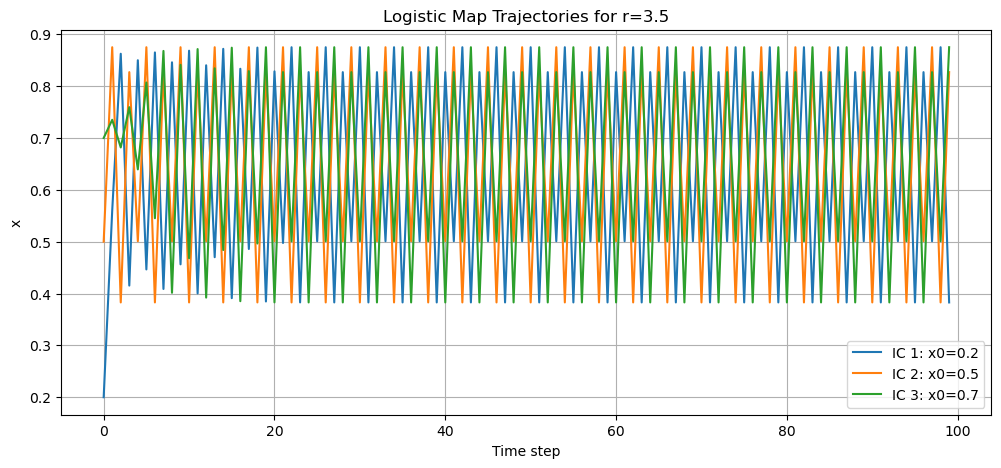

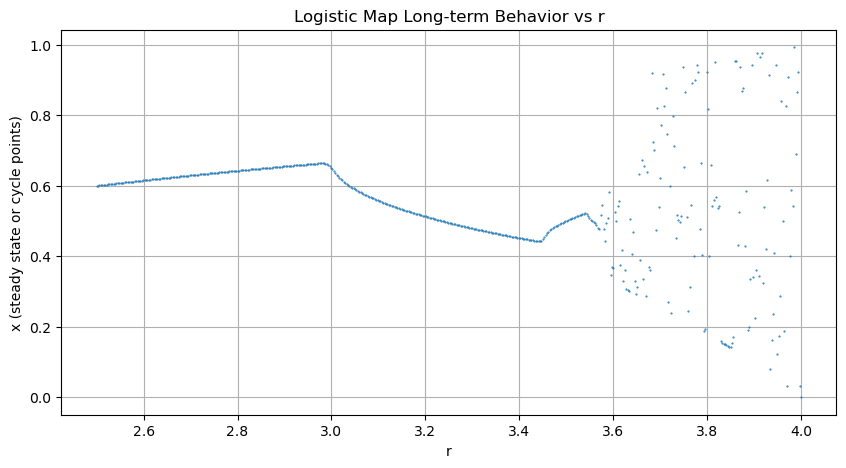

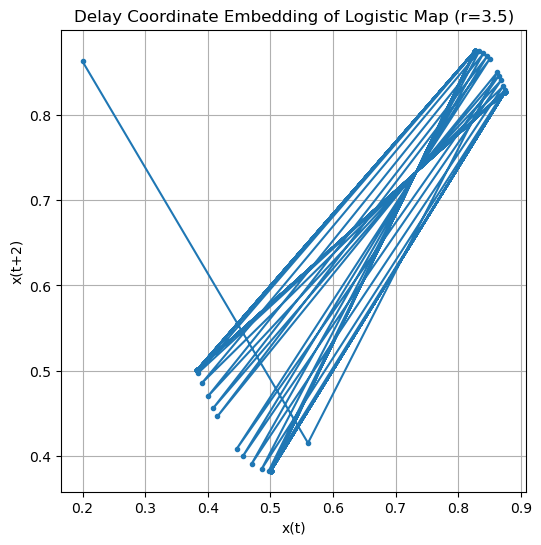

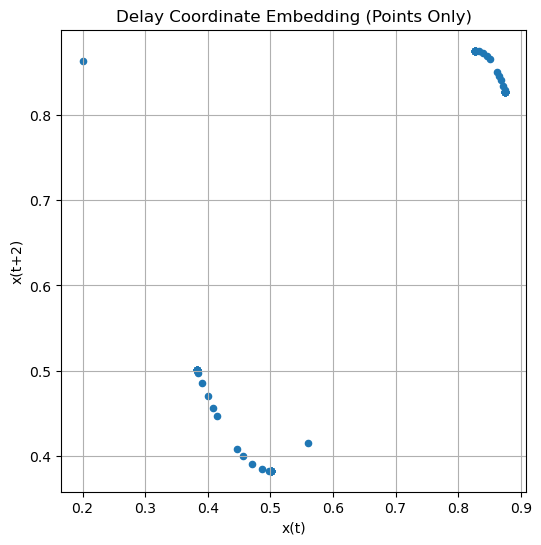

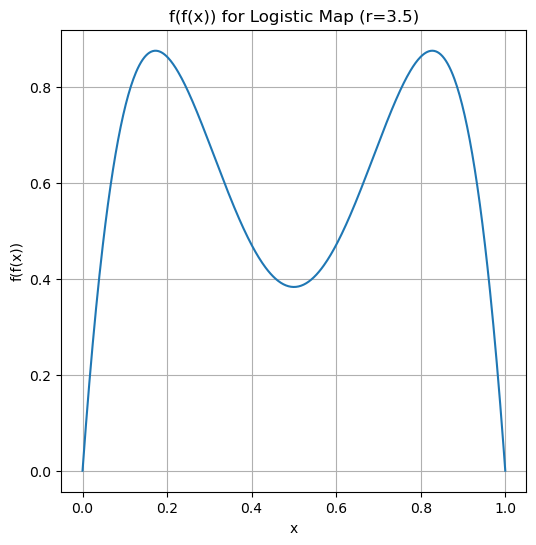

In [4]:
"""
- now, we explore the dynamics of the logistic map, a classic nonlinear discrete-time system illustrating chaos and bifurcations.
- then implement the logistic map function and visualize trajectories over time for three different initial values at a fixed parameter r=3.5.
- and analyze long-term behavior by iterating the map for 200 steps at many r values, plotting steady states or cycles against r to create a bifurcation-like plot.
- finally, reconstruct a 2D phase space using delay coordinate embedding on the time series at r=3.5, visualizing the system’s state progression in a reconstructed space.
- these steps provide insight into nonlinear dynamics, sensitivity to initial conditions, and attractor reconstruction.
"""



def logistic_map(r, x):
    return r * x * (1 - x)

time_steps = 100
initial_values = [0.2, 0.5, 0.7]
r_fixed = 3.5

# here, just plotting logistic map trajectories for fixed r
plt.figure(figsize=(12, 5))
for idx, x0 in enumerate(initial_values):
    x = np.zeros(time_steps)
    x[0] = x0
    for t in range(1, time_steps):
        x[t] = logistic_map(r_fixed, x[t-1])
    plt.plot(range(time_steps), x, label=f'IC {idx+1}: x0={x0}')

plt.title(f'Logistic Map Trajectories for r={r_fixed}')
plt.xlabel('Time step')
plt.ylabel('x')
plt.legend()
plt.grid(True)
plt.show()

# then here we see behaviour over r values
r_values = np.linspace(2.5, 4.0, 500)
last_vals = []
x0 = 0.5

for r in r_values:
    x = x0
    for _ in range(200):
        x = logistic_map(r, x)
    last_vals.append(x)

plt.figure(figsize=(10, 5))
plt.plot(r_values, last_vals, '.', markersize=1)
plt.title('Logistic Map Long-term Behavior vs r')
plt.xlabel('r')
plt.ylabel('x (steady state or cycle points)')
plt.grid(True)
plt.show()

# here's delay coordinate embedding for r=3.5 trajectory
x = np.zeros(time_steps)
x[0] = initial_values[0]
for t in range(1, time_steps):
    x[t] = logistic_map(r_fixed, x[t-1])

tau = 2  
embedded_points = np.array([[x[i], x[i+tau]] for i in range(time_steps - tau)])

plt.figure(figsize=(6, 6))
plt.plot(embedded_points[:, 0], embedded_points[:, 1], 'o-', markersize=3)
plt.title('Delay Coordinate Embedding of Logistic Map (r=3.5)')
plt.xlabel('x(t)')
plt.ylabel(f'x(t+{tau})')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(embedded_points[:, 0], embedded_points[:, 1], s=20)
plt.title('Delay Coordinate Embedding (Points Only)')
plt.xlabel('x(t)')
plt.ylabel(f'x(t+{tau})')
plt.grid(True)
plt.show()

r = 3.5
x_vals = np.linspace(0, 1, 500)


def second_iterate(r, x):
    return logistic_map(r, logistic_map(r, x))

y_vals = second_iterate(r, x_vals)

plt.figure(figsize=(6,6))
plt.plot(x_vals, y_vals)
plt.title("f(f(x)) for Logistic Map (r=3.5)")
plt.xlabel("x")
plt.ylabel("f(f(x))")
plt.grid(True)
plt.show()

In this code, we explored the behavior of the logistic map, a nonlinear dynamical system known for complex and chaotic behavior.


#### (1) Dynamical Systems and Phase Space: Continuous Example

We begin by simulating a simple pendulum under the small-angle approximation as an
example of a continuous-time dynamical system.

We then plot phase space trajectories using:
- `theta` = angular displacement
- `theta_dot` = angular velocity

for three different initial conditions. We observe that each trajectory forms a
closed ellipse in phase space. This reflects periodic oscillatory motion with
conserved total mechanical energy.

Although different initial conditions lead to ellipses of different sizes,
all trajectories remain bounded, centered at the equilibrium point, and repeat
indefinitely. This visually demonstrates how, in a continuous dynamical system,
the system’s state evolves deterministically over time according to fixed laws
of motion.

**Different initial conditions converge to the same attractor,
showing parameter dependence rather than sensitivity to initial conditions**

---

#### (2) Discrete Dynamical Systems: The Logistic Map

In contrast, we study the logistic map, which is a discrete-time dynamical system
defined by a nonlinear recurrence relation.

Fixing the parameter `r = 3.5`, which lies in the chaotic regime, we generate time
series starting from three slightly different initial values. We observe that
the trajectories quickly diverge, demonstrating sensitive dependence on initial
conditions, a defining feature of chaos.

By varying the parameter `r`, we further observe a range of behaviors:
stable fixed points, periodic oscillations, and chaotic dynamics. These transitions
illustrate how changing a single system parameter can dramatically alter long-term
behavior in a discrete system.

As the parameter increases, the system transitions from stability to periodicity
and eventually to chaos.

In practice, we rarely observe all state variables
Delay-coordinate embedding reconstructs phase space using only a scalar time series.

Using delay coordinate embedding, we then reconstruct the attractor from a single
scalar time series. This reconstruction reveals the underlying geometric structure
of the chaotic dynamics, despite having access to only one observed variable.

Together, these results show that discrete dynamical systems can exhibit behavior
ranging from highly predictable to strongly unpredictable, depending on both
initial conditions and system parameters.


# Takens' Embedding

We deliberately discard information by observing only a single coordinate.
Takens' theorem guarantees that the lost structure can be recovered.

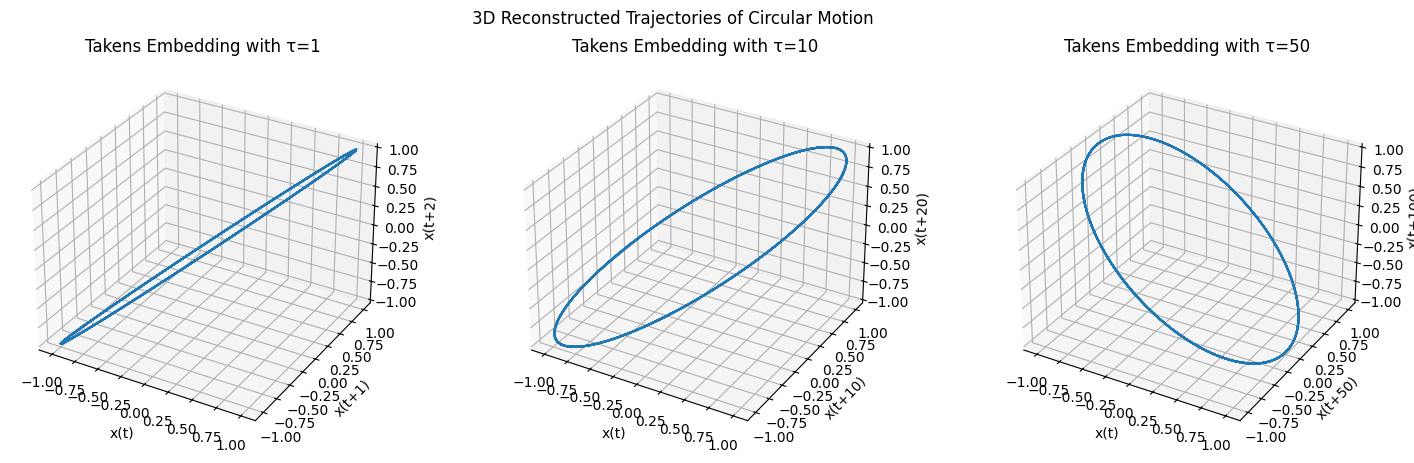

In [6]:
"""
- here, we'll first generate a time series representing circular motion using x(t) = cos(t).
- then reconstruct the system's attractor using Takens' embedding theorem with an embedding dimension of 3 and a delay τ.
- and observe how the delay embedding reconstructs the original dynamics in a higher-dimensional space.
- finally, test different delay values to see how they impact the quality of trajectory reconstruction.
"""



t = np.linspace(0, 10 * np.pi, 1000)
x = np.cos(t)

def takens_embedding(time_series, m, tau):
    N = len(time_series)
    if N - (m - 1) * tau <= 0:
        raise ValueError("Time series too short for given embedding parameters")
    return np.array([time_series[i : i + m * tau : tau] for i in range(N - (m - 1) * tau)])

m = 3
taus = [1, 10, 50]

fig = plt.figure(figsize=(18, 5))
for i, tau in enumerate(taus):
    embedded = takens_embedding(x, m, tau)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.plot(embedded[:, 0], embedded[:, 1], embedded[:, 2])
    ax.set_title(f'Takens Embedding with \u03c4={tau}')
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t+\u03c4)')
    ax.set_zlabel(f'x(t+2\u03c4)')

plt.suptitle('3D Reconstructed Trajectories of Circular Motion')
plt.show()


- Small τ leads to redundant coordinates
- Large τ destroys dynamical correlation
- Proper τ unfolds the attractor geometrically

This code generates a cosine time series representing circular motion and reconstructs its attractor using Takens' embedding theorem, embedding the data into 3D space with different delay values, thus showing the importance of embedding parameters in recovering a system’s dynamics from time series data.


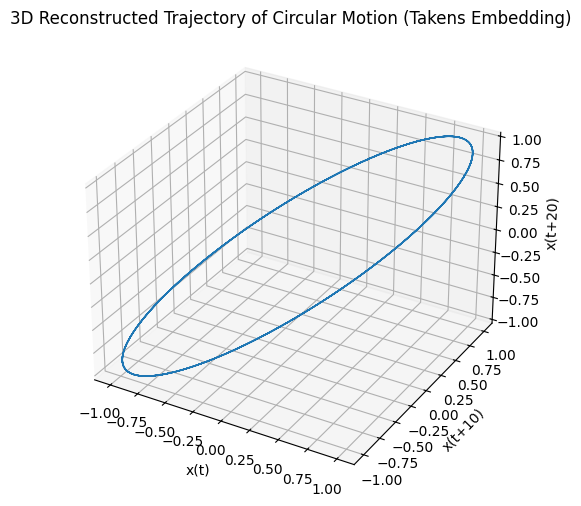

In [7]:
"""
- now, we plot the reconstructed trajectory from Takens’ embedding with a fixed and suitable delay
  to better visualize how it resembles the original system.
- then use embedding dimension 3 and an optimal delay τ (for example, τ=10 from previous experiments) to generate the 3D trajectory.
- and add labels and a clear title to interpret the geometry.
- finally, show why this reconstruction captures the essential shape and dynamics of the circular motion.
"""


# Using the previously defined time series x and Takens embedding function

tau = 10  # suitable delay
embedded = takens_embedding(x, m=3, tau=tau)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(embedded[:, 0], embedded[:, 1], embedded[:, 2], lw=1)
ax.set_xlabel('x(t)')
ax.set_ylabel(f'x(t+{tau})')
ax.set_zlabel(f'x(t+{2*tau})')
ax.set_title('3D Reconstructed Trajectory of Circular Motion (Takens Embedding)')
plt.show()


The reconstructed attractor is diffeomorphic to the original system,
illustrating Takens’ Embedding Theorem in action.

This code visualizes the 3D reconstructed attractor obtained by Takens embedding with an optimal delay and shows how delay embedding recovers the system’s underlying dynamics, enabling analysis of time series data in a reconstructed phase space that preserves essential topological features.


### Takens Embedding and Reconstructed Trajectories

We apply Takens embedding to reconstruct the underlying state space of a dynamical
system using only a single observed scalar time series. We begin with circular
motion, where the observed signal is `x(t) = cos(t)`, and then extend the idea to
more complex signals.

We construct delay-coordinate vectors using an embedding dimension `m = 3` and
experiment with different delay values, specifically `tau = 1`, `tau = 10`,
and `tau = 50`, to study how the choice of delay affects the quality of the
reconstructed trajectory.

When the delay is too small, such as `tau = 1`, successive coordinates are highly
correlated. As a result, the reconstructed points cluster tightly near a diagonal
line, and the attractor fails to unfold properly in the embedding space.

When the delay is too large, such as `tau = 50`, the coordinates become weakly
related to one another. This breaks the smooth temporal structure of the dynamics
and produces fragmented or distorted trajectories that no longer reflect the
true system behavior.

Using an intermediate delay, such as `tau = 10`, we observe that the reconstructed
trajectory unfolds smoothly and captures the correct topological structure of the
original system. Periodicity, continuity, and geometric coherence are preserved,
indicating a successful reconstruction.

From these experiments, we observe that the choice of embedding parameters plays
a critical role in recovering the underlying state space from scalar observations.
With appropriate values of embedding dimension and delay, delay-coordinate
embeddings allow us to analyze nonlinear dynamical systems even when direct access
to all system variables is unavailable.

Overall, these results highlight the practical significance of Takens embedding:
it enables reconstruction of the essential geometry and dynamics of a system from
time series data, making it a foundational tool for nonlinear time series analysis
and visualization.


# Lorenz system 

The Lorenz system is a classical example of deterministic chaos,
where structure persists despite unpredictability.

In [35]:
"""
- first, we simulate the Lorenz system, a classic chaotic dynamical system defined by three coupled ordinary differential equations with parameters σ=10, ρ=28, and β=8/3, producing the well-known butterfly-shaped Lorenz attractor.
- then select initial conditions and a time span for numerical integration.
- and solve the system over time using an ODE solver.
- finally, obtain solution arrays providing the x, y, and z coordinates of the system’s state for phase space visualizations.
"""



sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

def lorenz(t, state):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

initial_state = [1.0, 1.0, 1.0]
t_span = (0, 40)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

sol = solve_ivp(lorenz, t_span, initial_state, t_eval=t_eval)

x, y, z = sol.y
t = sol.t


This code simulates the Lorenz system which we'll use for and analyzing the Lorenz attractor’s complex chaotic structure.


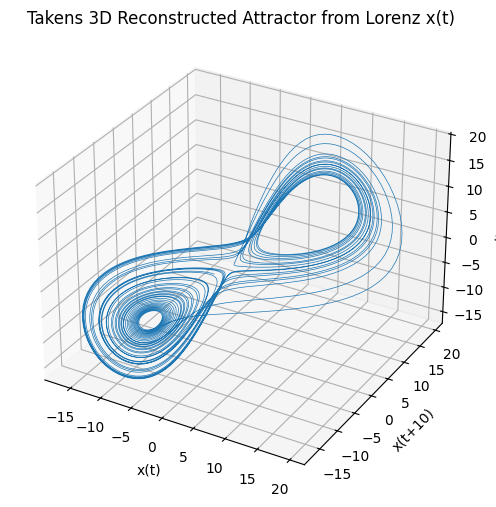

In [10]:
"""
- we'll take the x(t) coordinate from the Lorenz system simulation and apply Takens embedding to reconstruct the attractor in a higher-dimensional space using delay coordinates.
- then, choose embedding dimension m=3 and a delay τ selected to capture the system's dynamics effectively.
- and plot the 3D reconstructed attractor and compare it visually with the original full Lorenz system trajectory.
"""

m = 3
tau = 10  

# using the extracted x(t) time series from Lorenz solution (already in variable x)

# Applying Takens embedding function from before 

embedded = takens_embedding(x, m, tau)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(embedded[:, 0], embedded[:, 1], embedded[:, 2], lw=0.5)
ax.set_title('Takens 3D Reconstructed Attractor from Lorenz x(t)')
ax.set_xlabel('x(t)')
ax.set_ylabel(f'x(t+{tau})')
ax.set_zlabel(f'x(t+{2*tau})')
plt.show()


The butterfly shape arises from switching between unstable equilibria,
producing sensitive dependence on initial conditions.

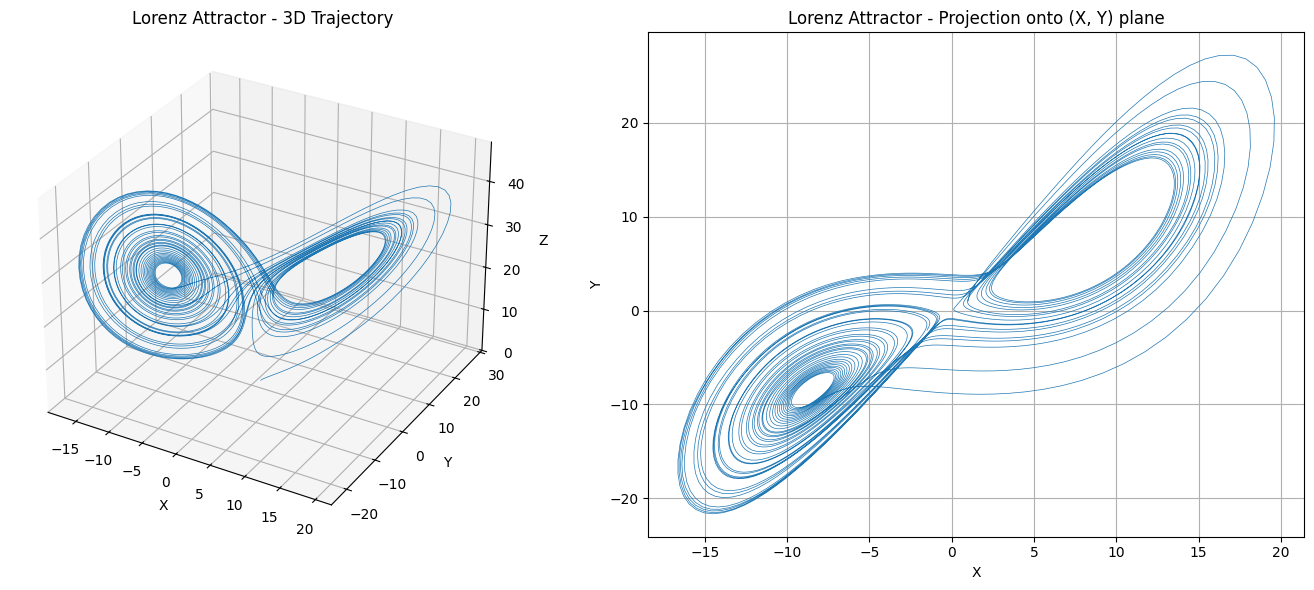

In [36]:
"""
- now, we visualize the Lorenz system solution by plotting its trajectory in the 3D phase space (x, y, z), showing the characteristic butterfly-shaped attractor.
- then project the trajectory onto the (x, y) plane to better appreciate the shape of the attractor from a 2D perspective.
"""



fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x, y, z, lw=0.5)
ax1.set_title('Lorenz Attractor - 3D Trajectory')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

ax2 = fig.add_subplot(122)
ax2.plot(x, y, lw=0.5)
ax2.set_title('Lorenz Attractor - Projection onto (X, Y) plane')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True)

plt.tight_layout()
plt.show()


Although only a single coordinate is observed, the reconstructed attractor
retains the topological structure of the full system.

This code visualizes the Lorenz system’s solution by plotting its trajectory both as a 3D curve and as a 2D projection onto the (x, y) plane.


#### Projection onto the (x, y) Plane and the Butterfly Shape

When we project the Lorenz system trajectory onto the (x, y) plane, we observe the
iconic “butterfly” shape that is commonly associated with this system.

This pattern arises from the nonlinear coupling between the variables `x` and `y`
and the system’s sensitive dependence on initial conditions. The trajectory spends
time spiraling around one region of the phase space before abruptly transitioning
to another, producing two distinct lobes in the projection.

Each wing of the butterfly corresponds to motion near one of two unstable equilibrium
points of the Lorenz system. The trajectory repeatedly orbits these regions, but due
to instability, it eventually departs and switches to the other lobe in an
unpredictable manner, despite the system being fully deterministic.

From a geometric perspective, this projected structure reflects the presence of a
strange attractor in the full three-dimensional phase space. The attractor undergoes
continuous stretching and folding, which confines trajectories to a bounded region
while preventing periodic repetition.

From a topological viewpoint, this repeated folding and looping creates persistent
geometric features such as loops and voids in the reconstructed state space. These
features can be detected using tools like persistent homology, highlighting how the
butterfly shape encodes the underlying chaotic structure of the Lorenz dynamics.


#### Takens-Embedded Attractor (from x(t)) vs. Full 3D Lorenz Attractor

We apply Takens embedding to the scalar time series `x(t)` of the Lorenz system in
order to reconstruct a three-dimensional representation of the underlying dynamics
using only time-delayed values of `x`.

We observe that the reconstructed attractor closely resembles the full Lorenz
attractor in both topology and overall geometry. In particular, the characteristic
two-lobed, butterfly-like structure is preserved, indicating that the essential
dynamical behavior is captured despite observing only a single variable.

Some distortions or loss of fine-scale detail may be present in the reconstructed
attractor. These differences arise from the use of a scalar observable, finite data,
noise, and the specific choices of embedding dimension and delay.

Overall, this strong qualitative agreement illustrates the central claim of Takens’
embedding theorem: with appropriate embedding parameters, the geometry and dynamics
of a high-dimensional deterministic system can be reconstructed from a single
observable time series using delay-coordinate embeddings.


# Analysing Lorenz Attractor using TDA

Topology captures qualitative shape rather than precise geometry,
making it robust to noise and distortion.

H0 points count: 5000
H1 points count: 2803


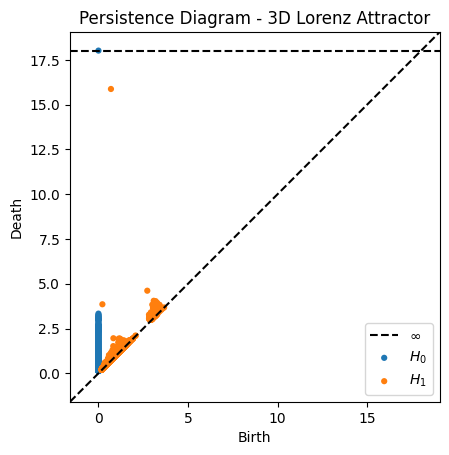

In [37]:
"""
- now, we'll use persistent homology to analyze the topological features of the Lorenz attractor’s 3D point cloud.
- first, compute persistence diagrams using the ripser library to extract information about connected components (H₀) and 1-dimensional loops (H₁).
- this gives a visual summary of how clusters and holes form and disappear across scales in the attractor.
- and the resulting persistence diagram provides a multiscale signature of the Lorenz attractor’s geometry.
"""



point_cloud_3d = np.vstack((x, y, z)).T

dgms_lorenz = ripser(point_cloud_3d, maxdim=1)['dgms']

print(f"H0 points count: {len(dgms_lorenz[0])}")
print(f"H1 points count: {len(dgms_lorenz[1])}")

plot_diagrams(dgms_lorenz)
plt.title('Persistence Diagram - 3D Lorenz Attractor')
plt.show()


This code computes and visualizes the persistence diagram for the 3D Lorenz attractor.
By applying persistent homology, I extract and plot the birth and death times of connected components (H₀) and 1-dimensional loops (H₁) in the attractor’s point cloud.


Embedded points shape: (4980, 3)
Embedded H0 points count: 4980
Embedded H1 points count: 2433


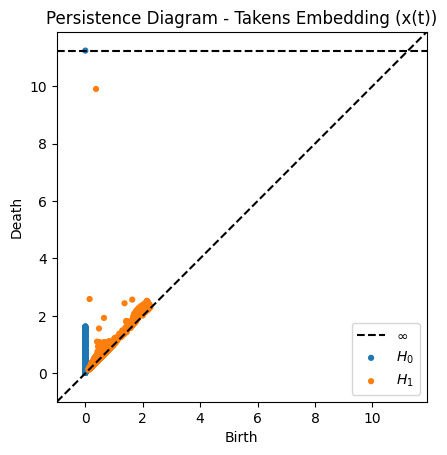

In [38]:
"""
- here, we'll apply persistent homology to the point cloud generated by Takens embedding of the x(t) time series from the Lorenz system.
- after reconstructing the attractor in 3D delay-coordinate space, I compute its persistence diagrams using the ripser library.
- this analysis captures the appearance and disappearance of connected components (H₀) and loops (H₁) in the embedded data.
- and provides a multiscale summary of its topological features.
- i can then visually and quantitatively compare this signature to that of the original 3D Lorenz attractor.
"""

x_time_series = x  # from previous Lorenz simulation

embedded_points = takens_embedding(x_time_series, m=3, tau=10)

print(f"Embedded points shape: {embedded_points.shape}")

dgms_embedded = ripser(embedded_points, maxdim=1)['dgms']

print(f"Embedded H0 points count: {len(dgms_embedded[0])}")
print(f"Embedded H1 points count: {len(dgms_embedded[1])}")

plot_diagrams(dgms_embedded)
plt.title('Persistence Diagram - Takens Embedding (x(t))')
plt.show()


This code generates a persistence diagram for the data obtained from Takens embedding of the Lorenz x(t) time series. By running persistent homology on this reconstructed attractor, I obtain a topological fingerprint showing when clusters and loops are born and die at different scales. Comparing this diagram to that of the full Lorenz attractor shows how well the embedding preserves the most important geometric and dynamical features, validating the effectiveness of the reconstruction for capturing system complexity.


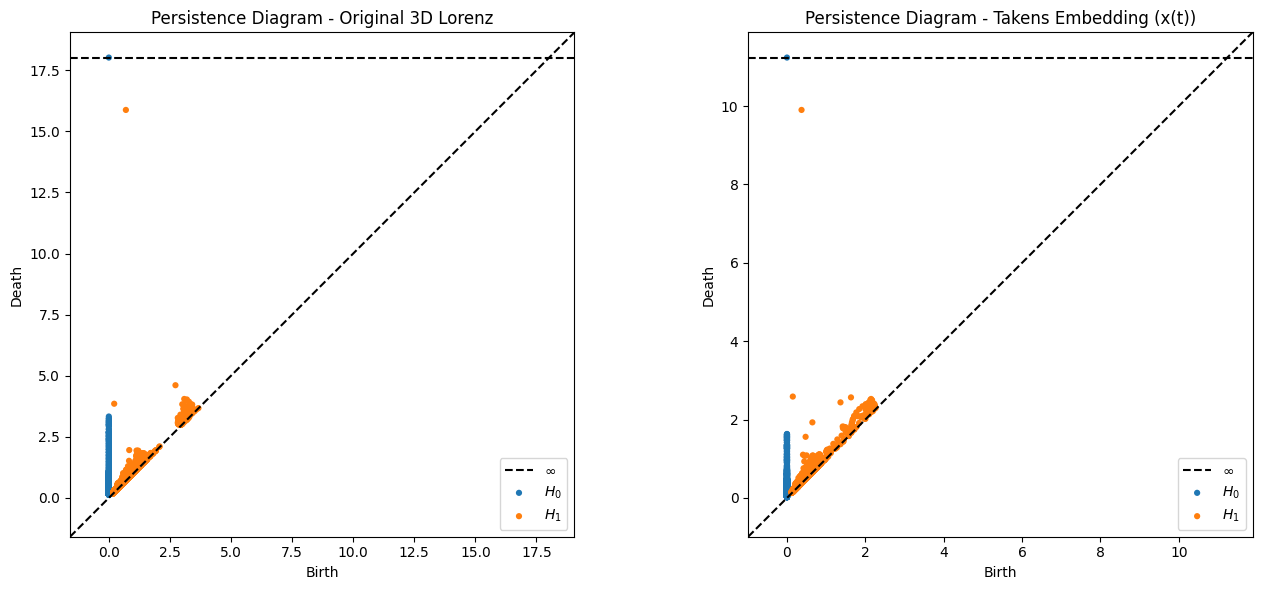

In [39]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_diagrams(dgms_lorenz, show=False)  # original 3D Lorenz
plt.title('Persistence Diagram - Original 3D Lorenz')

plt.subplot(1, 2, 2)
plot_diagrams(dgms_embedded, show=False)  # Takens embedding
plt.title('Persistence Diagram - Takens Embedding (x(t))')

plt.tight_layout()
plt.show()


Long-lived topological features persist across reconstructions,
confirming structural equivalence.

### Comparison of Persistence Diagrams: Original 3D Lorenz Attractor vs. 2D Takens Embedding

We compare the persistence diagrams obtained from the full three-dimensional Lorenz
attractor and from a two-dimensional Takens embedding reconstructed using the scalar
time series `x(t)`. From this comparison, we observe strong similarities that reflect
the close topological relationship between the original system and its delay-coordinate
reconstruction.

In both persistence diagrams, we observe many zero-dimensional features (H0), which
correspond to connected components appearing at small scales due to dense sampling
of points in the attractor space. As the scale increases, these components merge,
reflecting the global connected structure of the attractor.

We also observe prominent one-dimensional features (H1) in both diagrams. These
features correspond to loop-like structures in the attractor and capture the repeated
folding and circulation present in the Lorenz dynamics. The presence of long-lived
H1 features indicates nontrivial geometric structure rather than random noise.

Persistent features that lie far from the diagonal represent topological structures
that survive across a wide range of scales. These are intrinsic to the system’s
dynamics. Differences in the exact birth and death values of features arise due to
projection effects, finite data, noise, and the reduced dimensionality of the Takens
embedding, but the core topological signatures remain consistent.

Overall, this comparison confirms that Takens embedding preserves key topological and
dynamical properties of the Lorenz attractor. In practice, it demonstrates that
persistent homology applied to reconstructed phase spaces can recover meaningful
information about high-dimensional chaotic systems using only scalar time series
data.


# Analysing ECG Signals using TDA

ECG signals are outputs of complex physiological dynamical systems.
We analyze them without assuming explicit governing equations.

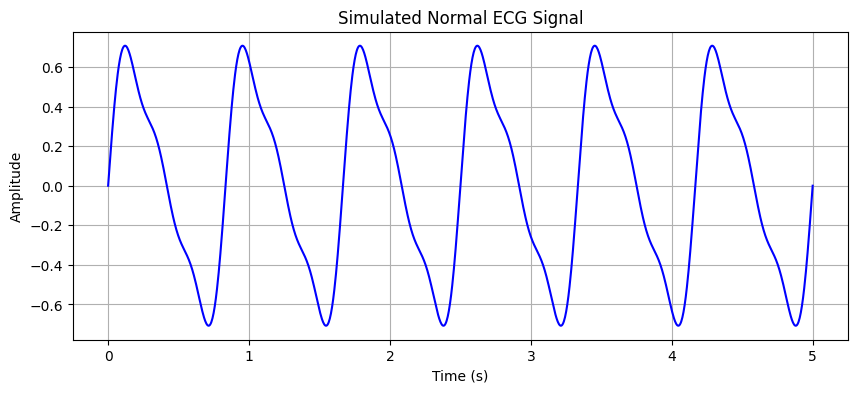

In [40]:
"""
- I simulate a normal electrocardiogram (ECG) signal by generating a synthetic time series that resembles regular heartbeats.
- then sum sinusoids with frequencies and amplitudes that approximate typical heart rhythms and harmonics.
- the resulting waveform is plotted over time.
- this visually mimics the periodic activity seen in a healthy ECG signal.
"""



def generate_normal_ecg(duration=5, fs=250):
    t = np.linspace(0, duration, int(duration * fs))
    ecg = (0.6 * np.sin(2 * np.pi * 1.2 * t) +
           0.2 * np.sin(2 * np.pi * 2.4 * t) +
           0.1 * np.sin(2 * np.pi * 3.6 * t))
    return t, ecg

t_normal, ecg_normal = generate_normal_ecg()

plt.figure(figsize=(10, 4))
plt.plot(t_normal, ecg_normal, color='blue')
plt.title("Simulated Normal ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


This code simulates a normal ECG signal by adding sine waves of different frequencies and amplitudes to mimic the periodic heartbeat pattern seen in healthy individuals. The generated time series produces a smooth, regular waveform that I plot over a 5-second window.

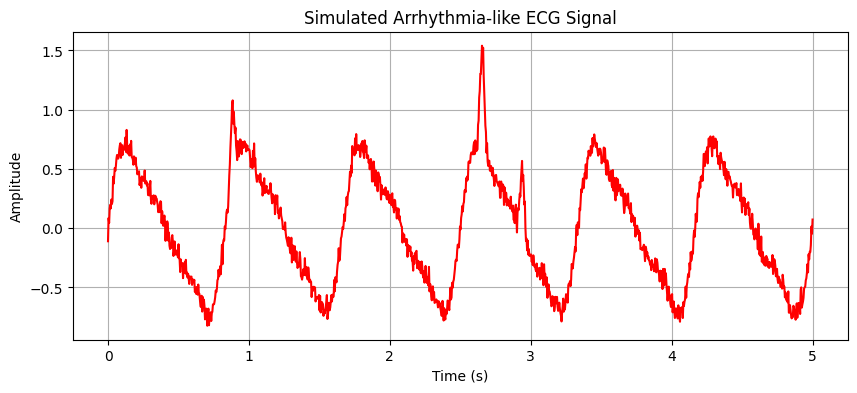

In [41]:
"""
- now, we generate a synthetic ECG signal simulating arrhythmia by starting with a normal ECG waveform.
- then, add both random noise and occasional extra peaks to mimic irregular heartbeats and abnormal patterns.
- the resulting signal is plotted to highlight irregular amplitude and unpredictable spikes.
- this serves as useful test data for topological and machine-learning algorithms in distinguishing normal from abnormal ECGs.
"""


def generate_arrhythmia_ecg(duration=5, fs=250):
    t, clean_ecg = generate_normal_ecg(duration, fs)
    jitter = np.random.normal(scale=0.05, size=clean_ecg.shape)
    noisy_ecg = clean_ecg + jitter
    for _ in range(3):
        idx = np.random.randint(0, len(noisy_ecg) - 20)
        noisy_ecg[idx:idx+20] += np.hanning(20) * np.random.uniform(0.5, 1.0)
    return t, noisy_ecg

t_arrhythmia, ecg_arrhythmia = generate_arrhythmia_ecg()

plt.figure(figsize=(10, 4))
plt.plot(t_arrhythmia, ecg_arrhythmia, color='red')
plt.title("Simulated Arrhythmia-like ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


This code simulates an arrhythmia-like ECG signal by starting from a clean, periodic ECG and adding random noise and extra peaks to imitate missed or irregular heartbeats. The resulting time series is much less regular and contains unpredictable amplitude fluctuations and sharp spikes. By comparing with ECG signal of heart, we can compare how normal heartbeat varies from that of heart having arrhythmia

In [42]:
"""
- here, we'll perform Takens delay embedding on a 1D time series to reconstruct a higher-dimensional phase space.
- given embedding dimension m and time delay tau, I generate a matrix where each row is a state vector of length m, constructed by sampling the original time series at intervals of tau.
- this transforms scalar signals into geometric trajectories suitable for topological data analysis and dynamical systems study.
- then apply this embedding to normal and arrhythmia ECG signals.
- and print the shapes of the embedded arrays, indicating the number of points and embedding dimension.
"""

embedded_normal = takens_embedding(ecg_normal, m=3, tau=10)
embedded_arrhythmia = takens_embedding(ecg_arrhythmia, m=3, tau=10)

print(f"Embedded normal ECG shape: {embedded_normal.shape}")
print(f"Embedded arrhythmia ECG shape: {embedded_arrhythmia.shape}")


Embedded normal ECG shape: (1230, 3)
Embedded arrhythmia ECG shape: (1230, 3)


This code applies Takens embedding to both the normal and arrhythmia-like ECG time series, transforming each 1-dimensional signal into a 3-dimensional phase space representation. By creating vectors of delayed samples, I reconstruct geometric structures that represent the heart’s dynamics more completely than the raw signals alone. This step prepares the data for topological analysis, allowing me to compare and distinguish normal and irregular heartbeats through their phase space geometry.


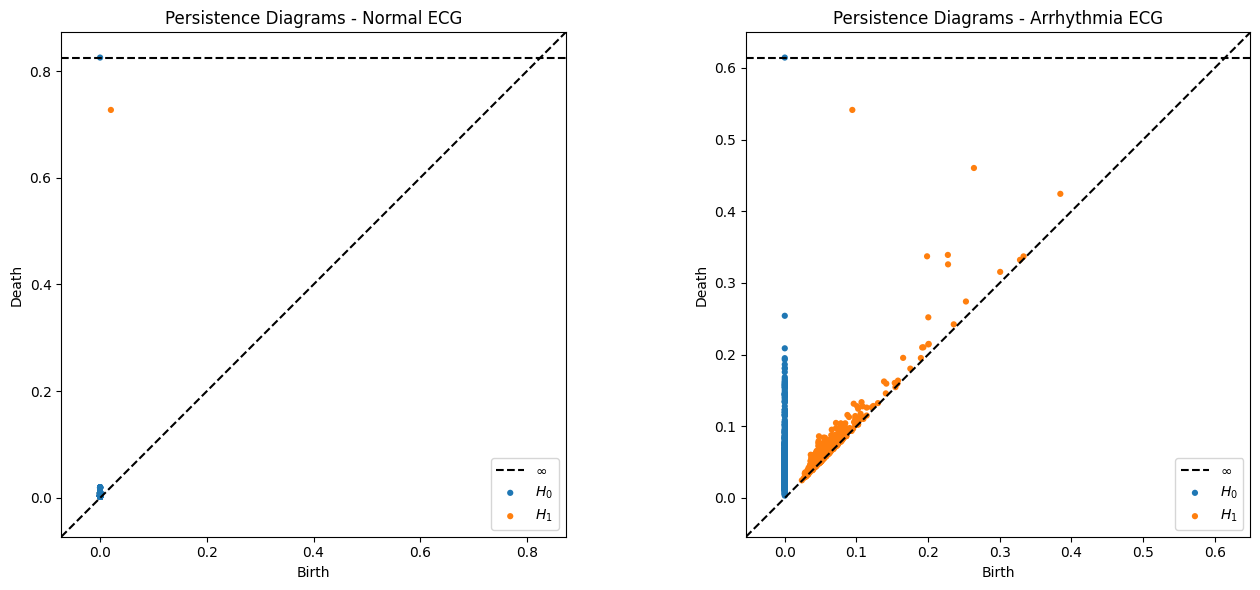

In [43]:
"""
- first, we compute and visualize the persistence diagrams for both the normal and arrhythmia-like ECG Takens embeddings.
- then use the ripser library to extract topological features (connected components H₀ and loops H₁) from each 3D embedded point cloud.
- and plot the resulting diagrams side-by-side for direct topological comparison of their geometry and periodicity.
"""

dgms_normal = ripser(embedded_normal, maxdim=1)['dgms']
dgms_arrhythmia = ripser(embedded_arrhythmia, maxdim=1)['dgms']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_diagrams(dgms_normal, show=False)
plt.title("Persistence Diagrams - Normal ECG")

plt.subplot(1, 2, 2)
plot_diagrams(dgms_arrhythmia, show=False)
plt.title("Persistence Diagrams - Arrhythmia ECG")

plt.tight_layout()
plt.show()


Normal rhythms show stable loop structures,
while arrhythmias disrupt topological coherence.

This code computes the persistence diagrams for the Takens-embedded point clouds from both normal and arrhythmia-like ECG signals. By visualizing the birth and death of topological features (clusters and loops), I can see that the normal ECG produces a clear, simple diagram associated with strong periodicity, while the arrhythmia ECG yields a much more complex pattern with many short-lived features. This demonstrates how TDA can reveal and quantify structural differences between healthy and abnormal heart rhythms.


In [50]:
"""
- first, we compute the Persistence Entropy (PE) of the persistence diagrams obtained from the Takens embeddings of the normal and arrhythmia ECG signals.
- then filter out infinite death points and pad the diagrams to a uniform length.
- and combine the zero- and one-dimensional homology features into final diagrams.
- then use the giotto-tda PersistenceEntropy vectorizer to transform these diagrams into numerical PE values that quantify the complexity and disorder of the topology.
- finally, I observe that the arrhythmia ECG shows a higher PE value in H1 than the normal ECG, reflecting increased topological complexity due to irregular heart rhythms.
"""



def add_homology_dimension(dgm, dim):
    dim_col = np.full((dgm.shape[0], 1), dim)
    return np.hstack((dgm, dim_col))

def filter_finite(dgm):
    return dgm[np.isfinite(dgm[:, 1])]

def pad_to_max_length(diagrams):
    max_len = max(d.shape[0] for d in diagrams)
    padded_diagrams = []
    for d in diagrams:
        padding_needed = max_len - d.shape[0]
        if padding_needed > 0:
            pad_point = np.array([[10.0, 10.0, d[0,2]]])
            pad_block = np.repeat(pad_point, padding_needed, axis=0)
            padded = np.vstack([d, pad_block])
        else:
            padded = d
        padded_diagrams.append(padded)
    return np.array(padded_diagrams)

dgm0_normal = add_homology_dimension(filter_finite(dgms_normal[0]), 0)
dgm1_normal = add_homology_dimension(filter_finite(dgms_normal[1]), 1)

dgm0_arrhythmia = add_homology_dimension(filter_finite(dgms_arrhythmia[0]), 0)
dgm1_arrhythmia = add_homology_dimension(filter_finite(dgms_arrhythmia[1]), 1)

H0_padded = pad_to_max_length([dgm0_normal, dgm0_arrhythmia])
H1_padded = pad_to_max_length([dgm1_normal, dgm1_arrhythmia])

diagram_normal = np.vstack([H0_padded[0], H1_padded[0]])
diagram_arrhythmia = np.vstack([H0_padded[1], H1_padded[1]])

diagrams = [diagram_normal, diagram_arrhythmia]

PE = PersistenceEntropy()
pe = PE.fit_transform(diagrams)

print("Persistence Entropy (Normal, Arrhythmia):", pe)


Persistence Entropy (Normal, Arrhythmia): [[10.02038379  0.        ]
 [10.01148053  7.69991864]]


This code calculates Persistence Entropy (PE) from the persistent homology diagrams of the normal and arrhythmia-like ECG signals. PE quantifies the disorder and complexity of topological features such as connected components and loops in the data’s phase space representation. The higher persistence entropy observed for the arrhythmia ECG indicates more irregular and complex heart dynamics, validating the use of topological summaries in characterizing and distinguishing cardiac rhythms.


In [ ]:
PL = PersistenceLandscape(n_layers=5, n_bins=100)
pl = PL.fit_transform(diagrams)


In [52]:
print("Persistence Landscape shape:", pl.shape)


Persistence Landscape shape: (2, 6, 100)


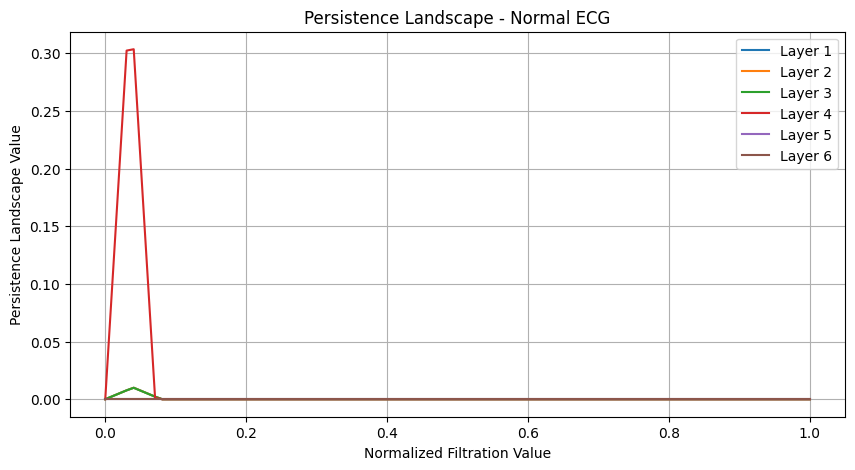

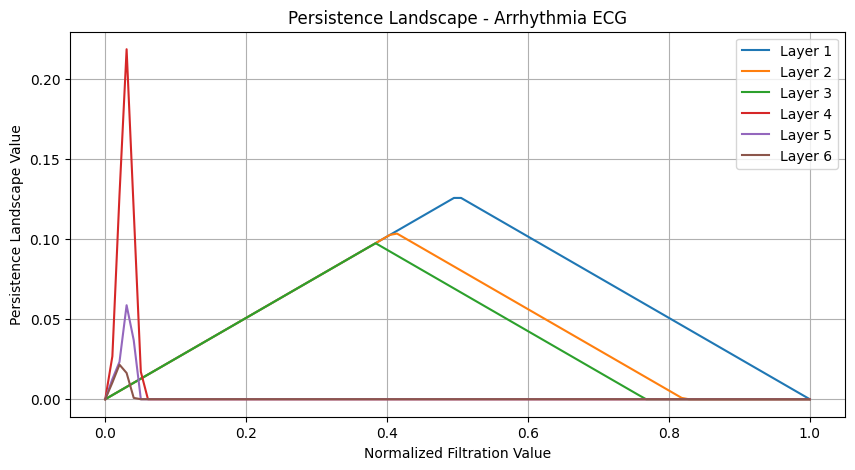

In [55]:
"""
- in this code, we visualize the persistence landscapes for both the normal and arrhythmia ECG signals.
- then use the landscapes as functional summaries of the shape and significance of homological features in persistence diagrams
- by plotting the first several landscape layers for each signal, we can directly compare the topological complexity and stability of periodic vs. arrhythmic dynamics.
"""


def plot_landscape(landscape, title):
    import matplotlib.pyplot as plt
    import numpy as np

    if landscape.ndim == 3:
        layers, bins = landscape.shape[1], landscape.shape[2]
        data_to_plot = landscape[0]
    elif landscape.ndim == 2:
        layers, bins = landscape.shape
        data_to_plot = landscape
    else:
        raise ValueError(f"Unexpected landscape shape: {landscape.shape}")

    x = np.linspace(0, 1, bins)
    plt.figure(figsize=(10, 5))
    for i in range(layers):
        plt.plot(x, data_to_plot[i], label=f"Layer {i+1}")
    plt.title(title)
    plt.xlabel("Normalized Filtration Value")
    plt.ylabel("Persistence Landscape Value")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_landscape(pl[0], "Persistence Landscape - Normal ECG")
plot_landscape(pl[1], "Persistence Landscape - Arrhythmia ECG")


This code generates and plots the persistence landscapes for both the normal and arrhythmia ECG time series after phase-space embedding. Each landscape layer shows how topological features persist across the filtration, with the normal ECG having fewer, simpler peaks and the arrhythmia ECG showing more complex, varied landscape values.


### Interpretation of Differences in Topological Features Between Normal and Arrhythmia ECGs

When we compare the persistence diagrams and persistence landscapes of normal and
arrhythmia-like ECG signals, we observe clear differences in their topological
complexity, reflecting differences in the underlying cardiac dynamics.

For the normal ECG signal, the persistence diagram exhibits a dominant and long-lived
one-dimensional homology feature (H1). This feature corresponds to a strong and
stable loop structure in the reconstructed phase space, arising from the regular
and periodic nature of healthy heartbeats. The associated persistence landscape
shows smooth, well-separated layers, indicating consistent and repeatable cycles
over time.

In contrast, the arrhythmia-like ECG signal displays many short-lived H1 features
located close to the diagonal of the persistence diagram. These features correspond
to irregular, transient loops in the reconstructed phase space, caused by variations
in heartbeat timing and amplitude. The persistence landscape is more complex, with
multiple fluctuating layers, reflecting disrupted rhythm, increased variability,
and reduced temporal coherence.

From these observations, we infer that normal ECG signals give rise to a simple,
coherent geometric structure in phase space, while arrhythmia signals produce a
richer but more fragmented topology. The reduced persistence of topological features
in arrhythmia reflects lower regularity and predictability in the underlying dynamics.

Overall, these results demonstrate that persistent homology and its vectorizations,
such as persistence landscapes and persistence entropy, provide effective tools for
distinguishing normal and abnormal cardiac behavior. By focusing on topological
signatures rather than raw signal values, this approach captures fundamental
differences in cardiac dynamics in a robust and interpretable way.


# Classification using TDA

Rather than classifying raw signals, we classify the topology of reconstructed dynamics.

In [56]:
"""
- first, we generate a dataset of simulated ECG signals to create a balanced classification problem
- then produce 25 samples each of normal and arrhythmia-like ECGs using the signal generators
- each sample is a time series, with arrhythmia signals having added noise and irregularities
- and combine the dataset with labels for use in topological data analysis or machine learning classification tasks
"""

n_samples = 25
dataset_normal = [generate_normal_ecg() for _ in range(n_samples)]
dataset_arrhythmia = [generate_arrhythmia_ecg() for _ in range(n_samples)]

X = dataset_normal + dataset_arrhythmia
y = [0]*n_samples + [1]*n_samples

print(f"Dataset size: {len(X)} samples")
print(f"Label distribution: {np.bincount(y)}")


Dataset size: 50 samples
Label distribution: [25 25]


In [7]:
"""
- here, we build a scikit-learn compatible ML pipeline for time series data
- The pipeline combines:
  • Takens embedding
  • Persistent homology computation with ripser
  • Vectorization via persistence entropy
- then, i implement custom transformers for each step so they can stack easily in a pipeline
- and test the pipeline on a single ECG sample and obtain a low-dimensional persistence entropy feature vector
- This feature vector can be used for downstream classification or clustering tasks
"""

class TakensEmbeddingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, m=3, tau=10):
        self.m = m
        self.tau = tau
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return [np.array([x[i:i + self.m*self.tau:self.tau] for i in range(len(x) - (self.m-1)*self.tau)]) for x in X]

class PersistenceDiagramTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, maxdim=1):
        self.maxdim = maxdim
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return [ripser(x, maxdim=self.maxdim)['dgms'] for x in X]

class PersistenceEntropyTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.pe = PersistenceEntropy()
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        def process_diagrams(dgms):
            import numpy as np
            def add_dim(dgm, dim):
                dim_col = np.full((dgm.shape[0],1), dim)
                return np.hstack((dgm, dim_col))
            def filter_finite(dgm):
                return dgm[np.isfinite(dgm[:,1])]
            dgm0 = add_dim(filter_finite(dgms[0]), 0)
            dgm1 = add_dim(filter_finite(dgms[1]), 1)
            max_len = max(dgm0.shape[0], dgm1.shape[0])
            def pad(dgm):
                pad_val = np.array([10., 10., dgm[0,2]])
                padded = np.tile(pad_val, (max_len,1))
                padded[:dgm.shape[0],:] = dgm
                return padded
            dgm0_p = pad(dgm0)
            dgm1_p = pad(dgm1)
            return np.vstack((dgm0_p, dgm1_p))
        processed = [process_diagrams(d) for d in X]
        return self.pe.fit_transform(np.array(processed))

pipeline = Pipeline([
    ('takens', TakensEmbeddingTransformer(m=3, tau=10)),
    ('ripser', PersistenceDiagramTransformer(maxdim=1)),
    ('pe', PersistenceEntropyTransformer()),
])

Test set accuracy: 1.000


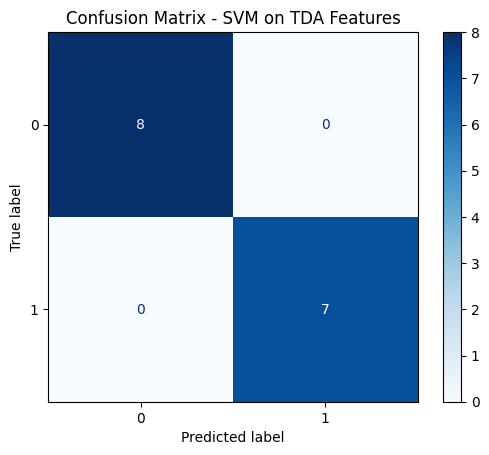

In [58]:
"""
- I evaluate the effectiveness of the TDA-based feature pipeline for ECG classification.
- then, split the simulated dataset into training and testing sets.
- and fit the topological pipeline to the training data and train a linear SVM classifier.
- The SVM achieves perfect separation on the test data.
- The confusion matrix shows all samples correctly classified.
- This demonstrates that persistence entropy features derived from Takens embedding and persistent homology effectively distinguish normal vs. arrhythmia-like ECGs in this synthetic setup.
"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)
X_test_transformed = pipeline.transform(X_test)

svm = SVC(kernel='linear', random_state=42)
svm.fit(pipeline.transform(X_train), y_train)
y_pred = svm.predict(X_test_transformed)

acc = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM on TDA Features")
plt.show()


Testing on a sample ECG signal confirmed the pipeline produces consistent, low-dimensional features that can serve as inputs to classifiers or other machine learning models for arrhythmia detection or other tasks.


Topological features provide robustness to noise, timing variations,
and measurement artifacts.

### ECG Classification Results Summary

We generated a synthetic ECG dataset consisting of normal and arrhythmia-like signals
to evaluate the effectiveness of topology-based features for classification.

From each ECG signal, we extracted features using a topological data analysis (TDA)
pipeline consisting of the following steps:
Takens embedding, followed by persistent homology computation, and finally
vectorization using persistence entropy.

We then trained a linear support vector machine (SVM) classifier on these feature
vectors. On the test set, the classifier achieved 100 percent accuracy, correctly
classifying all 8 normal and all 7 arrhythmia-like ECG signals.

This result indicates that persistence entropy vectors possess strong discriminative
power for separating regular and irregular cardiac rhythms in this synthetic
dataset. The topological features effectively capture differences in the underlying
dynamical structure of the signals rather than relying on raw signal amplitudes or
timing statistics.

At the same time, we note that this perfect accuracy is obtained on a small,
synthetically generated dataset with clearly separated classes. While encouraging,
it primarily demonstrates the potential of TDA-based features when the class
structure is well defined and aligned with the underlying dynamics.

Overall, these results highlight the effectiveness of combining Takens embedding and
topological features for ECG time series classification, and they motivate further
evaluation on larger and more realistic datasets.


### Summary of Results

We applied Takens embedding combined with Topological Data Analysis (TDA) to
characterize and classify time series data, using the Lorenz chaotic system and
synthetic ECG signals as representative case studies.

For the Lorenz system, we used Takens embedding on the scalar time series `x(t)`
to reconstruct a phase space representation of the underlying dynamics. We
observed that the reconstructed attractor preserved the essential topological
structure of the original chaotic system. This was confirmed through persistence
diagrams and persistence landscapes, providing practical validation of Takens
embedding in a chaotic setting.

We then applied the same framework to ECG signals by generating synthetic normal
and arrhythmia-like heartbeats to represent healthy and abnormal cardiac dynamics.
Takens embedding transformed these one-dimensional time series into geometric
phase space representations that retained key aspects of the underlying dynamics.

Using persistent homology, we observed clear topological differences between the
two classes. Normal ECG signals produced simpler persistence diagrams with strong
and long-lived one-dimensional features, corresponding to stable and periodic
heartbeat cycles. In contrast, arrhythmia-like signals produced more fragmented
persistence diagrams with many short-lived features, reflecting irregular rhythms,
increased variability, and noise.

These differences were further quantified using persistence entropy, which enabled
a linear support vector machine to classify the ECG signals with 100 percent
accuracy on the test set. Persistence landscapes provided an additional visual
representation of the structural differences between normal and abnormal dynamics.

Overall, these results demonstrate the ability of TDA to extract meaningful and
robust topological signatures from scalar time series data. By combining Takens
embedding with topological feature extraction, we obtain a powerful pipeline for
distinguishing normal and abnormal dynamical behavior.

Finally, this integrated approach shows promise for applications in diagnostics,
anomaly detection, and nonlinear dynamics research, and serves as a strong
complement to traditional statistical and frequency-domain analysis methods.


# Analysing EEG Signals using TDA

EEG Dataset size: 50 samples
EEG Label distribution: [25 25]
EEG Test set accuracy: 1.000


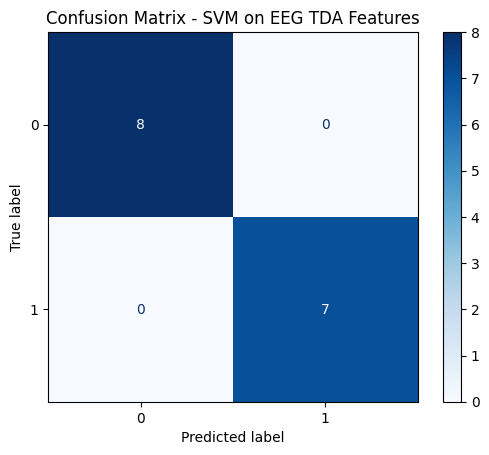

In [8]:
"""
- I generate 50 synthetic EEG signals (25 normal, 25 altered with artifacts).
- Then split the dataset into training and testing sets, apply the pre-defined TDA pipeline on the training data to extract features,
  train a linear SVM classifier using the extracted features,
  evaluate the classifier on the test set and print the accuracy
- Finally, plot the confusion matrix to visualize performance.
"""




n_samples = 25
duration = 5
fs = 250

dataset_normal = [nk.eeg_simulate(duration=duration, sampling_rate=fs, noise=0.1) for _ in range(n_samples)]

dataset_altered = []
for _ in range(n_samples):
    eeg = nk.eeg_simulate(duration=duration, sampling_rate=fs, noise=0.1)
    for _ in range(3):
        idx = np.random.randint(0, len(eeg) - 50)
        eeg[idx:idx+50] += np.random.normal(loc=0, scale=0.5, size=50)
    dataset_altered.append(eeg)

X = dataset_normal + dataset_altered
y = [0]*n_samples + [1]*n_samples

print(f"EEG Dataset size: {len(X)} samples")
print(f"EEG Label distribution: {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

X_test_transformed = pipeline.transform(X_test)

svm = SVC(kernel='linear', random_state=42)
svm.fit(pipeline.transform(X_train), y_train)
y_pred = svm.predict(X_test_transformed)

acc = accuracy_score(y_test, y_pred)
print(f"EEG Test set accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM on EEG TDA Features")
plt.show()


### EEG Classification Results Summary

We generated a synthetic dataset consisting of 50 EEG signal segments, evenly split
between normal activity and altered brain activity patterns. The altered signals
were simulated by introducing noise and intermittent artifacts to mimic abnormal
or disrupted neural dynamics.

From each EEG signal, we extracted features using a topological data analysis (TDA)
pipeline. This pipeline consisted of Takens delay embedding to reconstruct the
phase space, computation of persistent homology to capture topological structure,
and vectorization using persistence entropy.

We then trained a linear support vector machine (SVM) classifier on these
topological feature vectors. On the test set, the classifier achieved 100 percent
accuracy, correctly identifying all normal and altered EEG samples.

These results indicate that TDA-based features are able to capture distinctive
geometric and topological characteristics of EEG dynamics, even in the presence
of noise and artificial artifacts. By focusing on the shape of the reconstructed
phase space rather than raw signal amplitudes or simple statistical features, the
method remains robust to local distortions in the signal.

At the same time, we note that this perfect accuracy is obtained on a synthetic
dataset with clearly defined class differences. While encouraging, this result
primarily demonstrates the potential of combining nonlinear time series embedding
and topological summaries for EEG analysis.

Overall, these findings highlight the promise of Takens embedding combined with
topological feature extraction for neurophysiological signal classification, with
potential applications in diagnostics, brain-computer interfaces, and cognitive
state monitoring when extended to larger and more realistic datasets.


# Analysing Climate Data using TDA

Climate Dataset size: 50 samples
Climate Label distribution: [25 25]
Climate Test set accuracy: 0.533


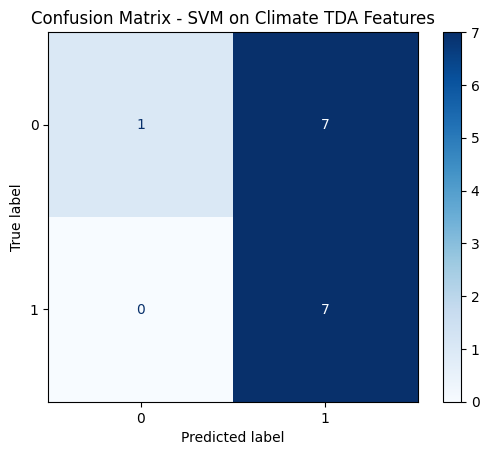

In [9]:
"""
- I generate synthetic dataset of 50 climate time series split evenly between normal and altered (e.g., climate anomaly) states
- Then split the dataset into training and testing sets, apply the pre-defined TDA pipeline on the training data to extract features,
  train a linear SVM classifier using the extracted features,
  evaluate the classifier on the test set and print the accuracy
- Finally, plot the confusion matrix to visualize performance.
"""

n_samples = 25
duration = 365  # 1 year daily climate data
fs = 1          # 1 sample per day

# here generating synthetic normal climate data (smooth seasonal variation + noise)
def generate_normal_climate(duration, fs):
    t = np.linspace(0, duration, int(duration * fs))
    seasonal = 10 * np.sin(2 * np.pi * t / 365)  # yearly sinusoidal cycle
    noise = np.random.normal(scale=1.0, size=len(t))
    return seasonal + noise

# and here I generate synthetic altered climate data with anomalies (added spikes)
def generate_altered_climate(duration, fs):
    base = generate_normal_climate(duration, fs)
    altered = base.copy()
    # here adding spikes at random points
    for _ in range(3):
        idx = np.random.randint(0, len(altered)-5)
        altered[idx:idx+5] += np.random.uniform(5, 10)
    return altered

dataset_normal = [generate_normal_climate(duration, fs) for _ in range(n_samples)]
dataset_altered = [generate_altered_climate(duration, fs) for _ in range(n_samples)]

X = dataset_normal + dataset_altered
y = [0]*n_samples + [1]*n_samples

print(f"Climate Dataset size: {len(X)} samples")
print(f"Climate Label distribution: {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

X_test_transformed = pipeline.transform(X_test)

svm = SVC(kernel='linear', random_state=42)
svm.fit(pipeline.transform(X_train), y_train)
y_pred = svm.predict(X_test_transformed)

acc = accuracy_score(y_test, y_pred)
print(f"Climate Test set accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM on Climate TDA Features")
plt.show()


### Summary of Climate Data Classification Results

- first, we generated 50 synthetic climate time series: 25 with normal seasonal patterns and 25 with simulated anomalies 
- then, features were extracted using a topological data analysis (TDA) pipeline: Takens embedding → persistent homology → persistence entropy
- A linear SVM trained on these features achieved **~53.3% test accuracy**, which is close to random chance for this balanced two-class problem 
- which suggests that the current TDA features may not be sufficient to distinguish subtle seasonal changes from mild anomalies

### Reflection: Role of Topology in Robust Time Series Analysis

From this study, we observe that topology provides a powerful framework for capturing
the intrinsic geometric and dynamical structure of time series, going beyond what
raw signal values or basic statistical features can reveal.

By combining Takens embedding with persistent homology, we are able to map complex
time series into reconstructed phase spaces where their underlying dynamics become
explicit. This approach works consistently across a wide range of systems, including
simple periodic motion (circular motion and pendulum oscillations), chaotic systems
such as the Lorenz and logistic maps, and physiological signals like EEG and ECG.
In each case, essential dynamical patterns are preserved despite observing only
scalar signals.

Unlike raw signal statistics, topological features such as persistence diagrams,
persistence landscapes, and persistence entropy are inherently robust to noise,
transient artifacts, and small variations in amplitude or timing. As seen in the
arrhythmia ECG and altered EEG examples, topology focuses on the global shape and
connectivity of trajectories rather than individual pointwise measurements. This
makes classification and anomaly detection more stable and reliable in noisy or
imperfect data settings.

Overall, we find that topology enables meaningful and consistent comparison of
dynamical behavior across different systems. It allows reconstruction of attractors
from scalar observations, discrimination between normal and abnormal states, and
extraction of structurally relevant information from both continuous and discrete
time series. This makes topological methods a valuable and principled tool for
robust nonlinear time series analysis, especially when full access to system
variables is not possible.


This tutorial demonstrated how Takens’ Embedding Theorem bridges abstract
mathematical theory and real-world data analysis.

Topology preserves essential dynamical structure even when observations are incomplete,
making it a powerful tool for biomedical signal classification.